In [8]:
import numba as nb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

## Tick Imbalance Bars — реализация по de Prado

### Идея

Стандартные бары (time, tick, volume, dollar) закрываются по фиксированному порогу — время, количество сделок, объём. Этот порог не зависит от того, что происходит на рынке прямо сейчас.

TIB закрывает бар иначе: когда накопленный дисбаланс между покупателями и продавцами превысил ожидаемый уровень. Бар формируется не по расписанию, а по факту информационного события.

---

### Механизм — шаг за шагом

**Шаг 1.** На каждом тике определяем агрессора:

```
b_t = +1  если агрессор покупает (side == "Buy")
b_t = -1  если агрессор продаёт  (side == "Sell")
```

**Шаг 2.** Накапливаем дисбаланс с начала бара:

```
θ_T = b_1 + b_2 + b_3 + ... + b_T
```

Если покупателей больше — `θ_T` растёт в плюс. Если продавцов больше — уходит в минус. В сбалансированном рынке болтается около нуля.

**Шаг 3.** Бар закрывается когда модуль накопленного дисбаланса превышает ожидаемый:

```
|θ_T| >= E[θ_T]
```

**Шаг 4.** Ожидаемый дисбаланс вычисляется по формуле:

```
E[θ_T] = E[T] × |2 × P_buy - 1|
```

Разберём что здесь что:

- `E[T]` — сколько тиков в среднем бывает в одном баре (обновляется после каждого закрытого бара)
- `P_buy` — какая доля тиков исторически является покупками (тоже обновляется)
- `|2 × P_buy - 1|` — мера перекоса: если `P_buy = 0.5` (рынок сбалансирован) → результат `0`, порог нулевой, бары закрываются очень часто; если `P_buy = 0.8` (сильное давление покупателей) → результат `0.6`, порог высокий, бары закрываются реже

---

### Как параметры обновляются автоматически

После каждого закрытого бара система обновляет `E[T]` и `P_buy` через EWMA:

```python
alpha = 2 / (span + 1)  # при span=200 → alpha ≈ 0.01

E_T   = alpha * длина_последнего_бара  + (1 - alpha) * E_T
P_buy = alpha * доля_покупок_в_последнем_баре + (1 - alpha) * P_buy
```

Что это означает на практике: каждый новый бар обновляет оценку на 1%, остальные 99% — это накопленная история. Система медленно и устойчиво адаптируется к текущему режиму рынка.

**Единственный гиперпараметр** — `span = 200`. Он контролирует скорость памяти:

```
span = 50   → быстрая адаптация, но нестабильно — реагирует на шум
span = 200  → баланс между стабильностью и адаптивностью
span = 2000 → очень медленная адаптация, игнорирует смену режима
```

---

### Поведение системы в разных режимах рынка

| Состояние рынка | P_buy | `\|2×P_buy−1\|` | Поведение |
|----------------|-------|-----------------|-----------|
| Сбалансированный | ~0.50 | ~0.00 | бары очень частые — порог почти нулевой |
| Умеренный тренд | ~0.65 | ~0.30 | бары средние |
| Сильное давление | ~0.80 | ~0.60 | бары реже и крупнее |

---

### Преимущество наших данных

Стандартная реализация TIB требует восстанавливать агрессора через tick rule — если цена выросла по сравнению с предыдущей сделкой, считаем тик покупкой, иначе продажей. Это приближение с потерями.

У нас `b_t` получен напрямую из колонки `side` Bybit — биржа явно указывает кто был агрессором в каждой сделке. Это устраняет основной источник ошибок и делает `θ_T` точным отражением реального order flow.

---

### Инициализация

Для самого первого бара истории ещё нет — берём статистику первого дня:

```python
E_T_init   = len(тиков_первого_дня) / 48  # предполагаем ~48 баров/день как старт
P_buy_init = среднее(b_t == 1)            # эмпирическая доля покупок за первый день
```

После этого состояние `E_T` и `P_buy` передаётся между днями непрерывно на всём периоде 2020–2026 — система накапливает историю без сбросов.

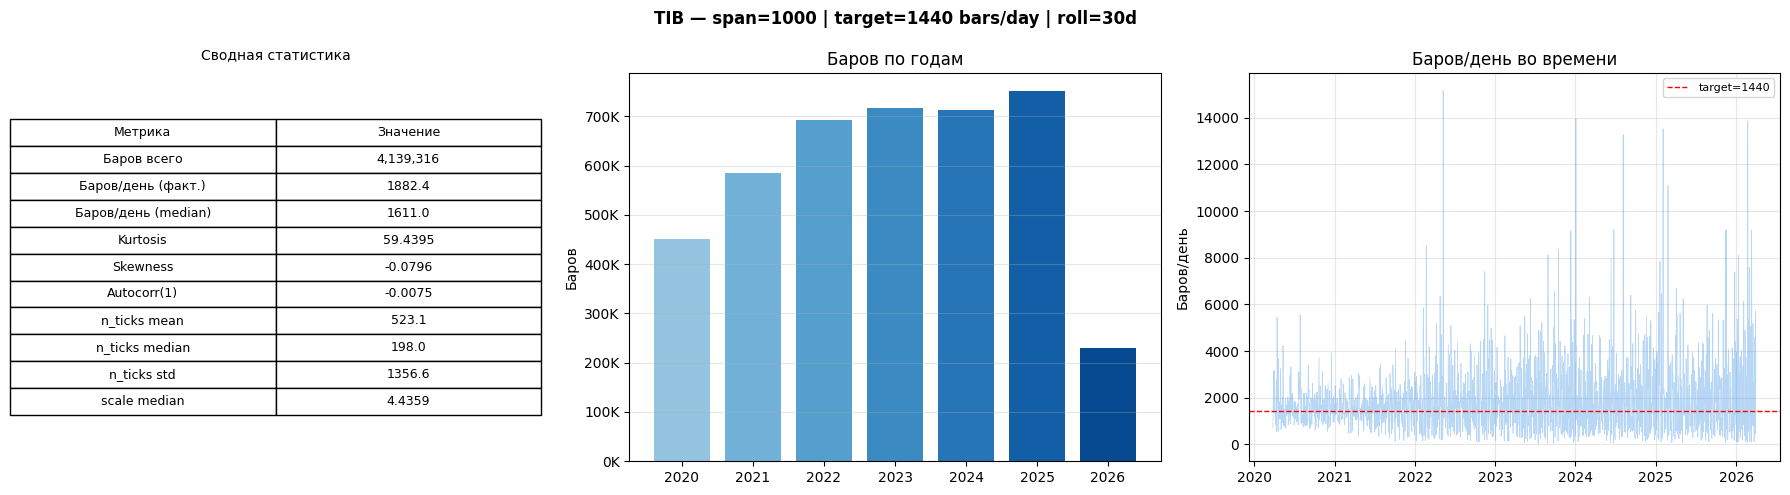

In [ ]:
TICKS_DIR        = Path("data/ticks/BTCUSDT")
BARS_DIR         = Path("data/bars")
BARS_DIR.mkdir(parents=True, exist_ok=True)

EWMA_SPAN        = 1000
ROLLING_DAYS     = 30
TARGET_BARS_DAY  = 1440
E_T_MIN_FRAC     = 0.50
E_T_MAX_FRAC     = 2.00
THETA_FLOOR_MULT = 1.00
CONTROL_STRENGTH = 0.25
SCALE_MIN        = 0.25
SCALE_MAX        = 20.0

BAR_PATH = BARS_DIR / f"tib_bars_recalibrated_span{EWMA_SPAN}_target{TARGET_BARS_DAY}_roll{ROLLING_DAYS}.parquet"
CTL_PATH = BARS_DIR / f"tib_control_span{EWMA_SPAN}_target{TARGET_BARS_DAY}_roll{ROLLING_DAYS}.csv"


@nb.njit
def _build_tib_numba(prices, b_t, sizes, dollars, timestamps,
                     E_T, ewma_bt, alpha, E_T_min, E_T_max,
                     E_T_target, threshold_scale, theta_floor_mult):
    n = len(prices)

    out_dt     = np.empty(n, dtype=timestamps.dtype)
    out_open   = np.empty(n, dtype=np.float64)
    out_high   = np.empty(n, dtype=np.float64)
    out_low    = np.empty(n, dtype=np.float64)
    out_close  = np.empty(n, dtype=np.float64)
    out_vol    = np.empty(n, dtype=np.float64)
    out_dlr    = np.empty(n, dtype=np.float64)
    out_nticks = np.empty(n, dtype=np.int64)
    out_theta  = np.empty(n, dtype=np.float64)

    n_bars    = 0
    theta     = 0.0
    bar_start = 0
    bar_high  = prices[0]
    bar_low   = prices[0]
    bar_vol   = 0.0
    bar_dlr   = 0.0

    theta_floor = theta_floor_mult * np.sqrt(max(E_T_target, 1.0))

    for i in range(n):
        b = b_t[i]
        p = prices[i]
        s = sizes[i]
        d = dollars[i]

        theta   += b
        bar_vol += s
        bar_dlr += d

        if p > bar_high: bar_high = p
        if p < bar_low:  bar_low  = p

        raw_expected = E_T * abs(ewma_bt)
        expected     = (theta_floor if raw_expected < theta_floor else raw_expected) * threshold_scale

        if abs(theta) >= expected:
            bar_len = i - bar_start + 1
            mean_bt = theta / bar_len

            out_dt[n_bars]     = timestamps[bar_start]
            out_open[n_bars]   = prices[bar_start]
            out_high[n_bars]   = bar_high
            out_low[n_bars]    = bar_low
            out_close[n_bars]  = p
            out_vol[n_bars]    = bar_vol
            out_dlr[n_bars]    = bar_dlr
            out_nticks[n_bars] = bar_len
            out_theta[n_bars]  = theta

            E_T     = alpha * bar_len + (1.0 - alpha) * E_T
            ewma_bt = alpha * mean_bt + (1.0 - alpha) * ewma_bt

            if E_T < E_T_min: E_T = E_T_min
            if E_T > E_T_max: E_T = E_T_max

            theta     = 0.0
            bar_start = i + 1
            bar_high  = prices[i + 1] if i + 1 < n else p
            bar_low   = prices[i + 1] if i + 1 < n else p
            bar_vol   = 0.0
            bar_dlr   = 0.0
            n_bars   += 1

    return (out_dt[:n_bars], out_open[:n_bars], out_high[:n_bars],
            out_low[:n_bars], out_close[:n_bars], out_vol[:n_bars],
            out_dlr[:n_bars], out_nticks[:n_bars], out_theta[:n_bars],
            E_T, ewma_bt, bar_start)


def build_tib(ticks, ewma_span, E_T, ewma_bt, E_T_min, E_T_max,
              E_T_target, threshold_scale, theta_floor_mult):
    if len(ticks) == 0:
        return pd.DataFrame(columns=["dt","open","high","low","close",
                                     "volume","dollar_volume","n_ticks","theta"]), E_T, ewma_bt, 0

    alpha  = 2.0 / (ewma_span + 1.0)
    result = _build_tib_numba(
        ticks["price"].values.astype(np.float64),
        ticks["b_t"].values.astype(np.int8),
        ticks["size"].values.astype(np.float64),
        ticks["dollar_value"].values.astype(np.float64),
        ticks["dt"].values,
        E_T, ewma_bt, alpha, E_T_min, E_T_max,
        E_T_target, threshold_scale, theta_floor_mult,
    )

    dt, open_, high, low, close, vol, dlr, nticks, theta, E_T_new, ewma_bt_new, next_idx = result

    df = pd.DataFrame({"dt": dt, "open": open_, "high": high, "low": low,
                       "close": close, "volume": vol, "dollar_volume": dlr,
                       "n_ticks": nticks, "theta": theta})
    return df, E_T_new, ewma_bt_new, next_idx


files = sorted(TICKS_DIR.glob("BTCUSDT*.parquet"))

daily_stats = []
for f in files:
    try:
        df = pd.read_parquet(f, columns=["b_t", "size"])
        df = df[df["size"] > 0]
        if len(df) == 0: continue
        daily_stats.append({"date": pd.Timestamp(f.stem.replace("BTCUSDT","")),
                             "n_ticks": len(df), "mean_bt": float(df["b_t"].mean())})
    except: pass

stats_df = pd.DataFrame(daily_stats).set_index("date").sort_index()
stats_df["roll_ticks"]       = stats_df["n_ticks"].rolling(ROLLING_DAYS, min_periods=1).median()
stats_df["target_ticks_bar"] = stats_df["roll_ticks"] / TARGET_BARS_DAY
stats_df["E_T_min_day"]      = stats_df["target_ticks_bar"] * E_T_MIN_FRAC
stats_df["E_T_max_day"]      = stats_df["target_ticks_bar"] * E_T_MAX_FRAC

init_slice   = stats_df.iloc[:min(ROLLING_DAYS, len(stats_df))]
E_T_init     = float(init_slice["target_ticks_bar"].median())
ewma_bt_init = float(init_slice["mean_bt"].mean())

if BAR_PATH.exists() and CTL_PATH.exists():
    df_tib     = pd.read_parquet(BAR_PATH)
    control_df = pd.read_csv(CTL_PATH, index_col=0, parse_dates=True)
else:
    _warm = pd.read_parquet(files[0], columns=["dt","price","size","b_t","dollar_value"])
    _warm = _warm[_warm["size"] > 0].head(5000).reset_index(drop=True)
    warm_row = stats_df.loc[pd.Timestamp(files[0].stem.replace("BTCUSDT",""))] \
               if pd.Timestamp(files[0].stem.replace("BTCUSDT","")) in stats_df.index \
               else stats_df.iloc[0]
    build_tib(_warm, EWMA_SPAN, E_T_init, ewma_bt_init,
              float(warm_row["E_T_min_day"]), float(warm_row["E_T_max_day"]),
              float(warm_row["target_ticks_bar"]), 1.0, THETA_FLOOR_MULT)

    all_bars        = []
    daily_control   = []
    carry_ticks     = None
    E_T             = E_T_init
    ewma_bt         = ewma_bt_init
    threshold_scale = 1.0
    t0              = time.time()

    for idx, f in enumerate(files):
        date_str = f.stem.replace("BTCUSDT", "")
        dt_day   = pd.Timestamp(date_str)

        if idx % 100 == 0:
            print(f"  [{idx+1:>4}/{len(files)}] {date_str} | E_T={E_T:>10.1f} | scale={threshold_scale:>6.3f}")

        try:
            day_ticks = pd.read_parquet(f, columns=["dt","price","size","b_t","dollar_value"])
        except: continue

        day_ticks = day_ticks[day_ticks["size"] > 0].reset_index(drop=True)
        if len(day_ticks) == 0: continue

        ticks = pd.concat([carry_ticks, day_ticks], ignore_index=True) \
                if carry_ticks is not None and len(carry_ticks) > 0 else day_ticks

        row        = stats_df.loc[dt_day] if dt_day in stats_df.index else stats_df.iloc[-1]
        E_T_target = float(row["target_ticks_bar"])
        E_T_min    = float(row["E_T_min_day"])
        E_T_max    = float(row["E_T_max_day"])
        E_T        = min(max(E_T, E_T_min), E_T_max)

        day_bars, E_T, ewma_bt, next_idx = build_tib(
            ticks, EWMA_SPAN, E_T, ewma_bt, E_T_min, E_T_max,
            E_T_target, threshold_scale, THETA_FLOOR_MULT)

        if len(day_bars) > 0: all_bars.append(day_bars)

        carry_ticks = ticks.iloc[next_idx:].copy().reset_index(drop=True) \
                      if next_idx < len(ticks) else None

        bars_today      = len(day_bars)
        threshold_scale = float(np.clip(threshold_scale * (max(bars_today,1)/TARGET_BARS_DAY)**CONTROL_STRENGTH,
                                        SCALE_MIN, SCALE_MAX))

        daily_control.append({"date": dt_day, "bars_today": bars_today,
                               "threshold_scale": threshold_scale, "E_T": E_T,
                               "E_T_target": E_T_target, "ewma_bt": ewma_bt})

    control_df = pd.DataFrame(daily_control).set_index("date").sort_index()
    df_tib     = pd.concat(all_bars, ignore_index=True)
    df_tib["dt"]  = pd.to_datetime(df_tib["dt"])
    df_tib        = df_tib.sort_values("dt").reset_index(drop=True)
    df_tib["ret"] = np.log(df_tib["close"] / df_tib["close"].shift(1))

    df_tib.to_parquet(BAR_PATH, compression="snappy", index=False)
    control_df.to_csv(CTL_PATH)


r       = df_tib["ret"].dropna()
n_days  = len(stats_df)
yearly  = df_tib.groupby(df_tib["dt"].dt.year).agg(bars=("dt","count"),
                                                     avg_n=("n_ticks","mean"),
                                                     med_n=("n_ticks","median")).reset_index()

rows = [{"Метрика": "Баров всего",          "Значение": f"{len(df_tib):,}"},
        {"Метрика": "Баров/день (факт.)",    "Значение": f"{len(df_tib)/n_days:.1f}"},
        {"Метрика": "Баров/день (median)",   "Значение": f"{control_df['bars_today'].median():.1f}"},
        {"Метрика": "Kurtosis",              "Значение": f"{r.kurtosis():.4f}"},
        {"Метрика": "Skewness",              "Значение": f"{r.skew():.4f}"},
        {"Метрика": "Autocorr(1)",           "Значение": f"{r.autocorr(lag=1):.4f}"},
        {"Метрика": "n_ticks mean",          "Значение": f"{df_tib['n_ticks'].mean():.1f}"},
        {"Метрика": "n_ticks median",        "Значение": f"{df_tib['n_ticks'].median():.1f}"},
        {"Метрика": "n_ticks std",           "Значение": f"{df_tib['n_ticks'].std():.1f}"},
        {"Метрика": "scale median",          "Значение": f"{control_df['threshold_scale'].median():.4f}"}]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"TIB — span={EWMA_SPAN} | target={TARGET_BARS_DAY} bars/day | roll={ROLLING_DAYS}d",
             fontsize=12, fontweight="bold")

axes[0].axis("off")
tbl = axes[0].table(cellText=[[r["Метрика"], r["Значение"]] for r in rows],
                    colLabels=["Метрика", "Значение"],
                    cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
axes[0].set_title("Сводная статистика", fontsize=10, pad=10)

axes[1].bar(yearly["dt"].astype(str), yearly["bars"],
            color=plt.cm.Blues(np.linspace(0.4, 0.9, len(yearly))))
axes[1].set_title("Баров по годам")
axes[1].set_ylabel("Баров")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e3:.0f}K"))
axes[1].grid(alpha=0.3, axis="y")

axes[2].plot(control_df.index, control_df["bars_today"], alpha=0.4, linewidth=0.5, color="#4C9BE8")
axes[2].axhline(TARGET_BARS_DAY, color="red", linewidth=1, linestyle="--", label=f"target={TARGET_BARS_DAY}")
axes[2].set_title("Баров/день во времени")
axes[2].set_ylabel("Баров/день")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()




Система отработала всю историю 2020–2026 без деградации: **4.1M баров**, медиана 1611 баров/день против цели 1440. На графике баров/день видно что система удерживает поток около цели — выбросы есть, но система возвращается к таргету.

Kurtosis = **59.44** — значительно хуже dollar bars (12.06) и volume bars (13.44). Это подтверждает основной вывод: на BTC tick imbalance — слабый сигнал из-за балансированного order flow.

---

## Почему потребовалось столько гиперпараметров

Каждый параметр добавлялся не по желанию, а как ответ на конкретный сбой системы. Ниже — что именно ломалось без каждого из них.

---

### `EWMA_SPAN = 1000`

Контролирует скорость памяти — как быстро система забывает старые бары при обновлении `E[T]` и `ewma_bt`:

```
alpha = 2 / (span + 1) = 0.002  →  каждый новый бар весит 0.2%
```

**Без него:** нужно задать хоть какое-то значение. При маленьком span (50) система реагирует на каждый шумный день и бросается в крайности — то 10000 баров/день, то 100. При большом span (5000) система вообще не адаптируется к смене режима. 1000 — компромисс, подобранный эмпирически.

---

### `ROLLING_DAYS = 30`

Окно скользящей медианы для расчёта `E_T_min`, `E_T_max`, `target_ticks_bar` каждый день.

**Без него:** система инициализируется один раз в начале и никогда не обновляет границы. BTC вырос с 9K тиков/день в 2020 до 2.5M в 2026 — в **280 раз**. Пороги 2020 года в 2024 дают либо один бар в неделю, либо 100000 баров в день. Система нерабочая.

---

### `TARGET_BARS_DAY = 1440`

Целевое число баров в день — используется для инициализации `E[T]` и для feedback-контроллера.

**Без него:** система не знает с чего начать. Первый `E[T]` берётся как `median_ticks / TARGET_BARS_DAY`. Если не задать target — первые бары будут случайными и EWMA начнёт с неправильной точки, из которой долго не выйдет.

---

### `E_T_MIN_FRAC = 0.50` и `E_T_MAX_FRAC = 2.00`

Жёсткие границы для `E[T]` — не позволяют ему уйти слишком далеко от текущего уровня ликвидности:

```
E_T_min = target_ticks_bar × 0.50
E_T_max = target_ticks_bar × 2.00
```

**Без них:** EWMA `E[T]` после нескольких аномальных дней (flash crash, новостной шок) улетает в значения которые не соответствуют реальной ликвидности. Видели в логах: `E_T = 46,749` после одного экстремального дня — дальше система не закрывала бары сутками.

---

### `THETA_FLOOR_MULT = 1.00`

Минимальный порог закрытия бара в шкале `θ`:

```
theta_floor = THETA_FLOOR_MULT × sqrt(E_T_target)
```

Формула взята из теории случайного блуждания: если `b_t` независимы, то время первого выхода за уровень `a` растёт как `a²`, то есть `a ~ sqrt(T)`.

**Без него:** когда рынок полностью сбалансирован (`P_buy ≈ 0.50`), `ewma_bt ≈ 0`, `E[θ_T] = E[T] × |2×0.5−1| = 0`. Порог нулевой — каждый тик закрывает бар. На выходе миллиарды баров, система схлопывается.

---

### `CONTROL_STRENGTH = 0.25`

Скорость feedback-контроллера — насколько агрессивно `threshold_scale` корректируется если баров в день стало больше или меньше цели:

```python
threshold_scale *= (bars_today / TARGET_BARS_DAY) ** CONTROL_STRENGTH
```

**Без него:** число баров гуляет от 7 до 14000 в день без какой-либо стабилизации — что видно на графике справа в ранних версиях. При `CONTROL_STRENGTH = 1.0` коррекция слишком агрессивная и сама создаёт осцилляции. `0.25` — четверть коррекции за один день, система медленно и устойчиво сходится к цели.

---

### `SCALE_MIN = 0.25` и `SCALE_MAX = 20.0`

Жёсткие границы для `threshold_scale` — защита от взрыва контроллера.

**Без них:** контроллер может уйти в `0` (каждый тик — бар, памяти хватает на несколько секунд) или в `∞` (бары перестают закрываться вообще). Оба сценария наблюдались в ранних прогонах. Конкретные значения `0.25` и `20.0` подобраны эмпирически — за пределами этого диапазона система необратимо деградирует.

---

### Главный вывод

Каждый параметр решал реальную проблему деградации. Но сам факт того что их потребовалось семь — это диагноз: **TIB не работает на BTC из коробки**. Система устойчива только с внешними костылями, каждый из которых подобран под исторические данные. Dollar bars дают лучший kurtosis с одним параметром — и не требуют ни одного из этих исправлений.

## Tick Runs Bars — концепция

### Разница между TIB и TRB

Оба типа баров измеряют дисбаланс между покупателями и продавцами. Разница в том **как именно** они это делают.

**TIB** считает разницу — покупки минус продажи:

```
θ_T = buy_count − sell_count
```

**TRB** берёт максимум одной стороны — без вычитания:

```
θ_T = max(buy_count, sell_count)
```

Конкретный пример — 10 тиков, 7 покупок и 3 продажи:

```
TIB:  θ_T = 7 − 3 = 4    → умеренный сигнал
TRB:  θ_T = max(7, 3) = 7 → сильный сигнал
```

TRB видит одностороннее давление сильнее — он не гасит сигнал противоположной стороной.

---

### Почему это важно на BTC

Главная проблема TIB на BTC — рынок почти всегда сбалансирован: `P_buy ≈ 0.50`. Маркетмейкеры эффективно уравновешивают поток покупок и продаж.

Посмотрим что происходит с порогом при `P_buy = 0.51`:

```
TIB порог: E_T × |2 × P_buy − 1|
           E_T × |2 × 0.51 − 1| = E_T × 0.02   ← почти ноль

TRB порог: E_T × max(P_buy, 1 − P_buy)
           E_T × max(0.51, 0.49) = E_T × 0.51  ← стабильно
```

`max(P_buy, 1−P_buy) ≥ 0.5` — **математически не может быть близким к нулю**. TRB не деградирует при сбалансированном рынке по конструкции, без дополнительных хаков.

---

### Что TRB обнаруживает в данных

Крупные игроки дробят ордера на тысячи маленьких сделок — iceberg orders, sweep orders, алгоритмическое исполнение. В потоке тиков это выглядит как длинная серия однонаправленных сделок с редкими перерывами:

```
Обычный рынок:  buy sell buy sell buy sell buy sell
Крупный игрок:  buy buy buy buy buy sell buy buy buy
```

TRB обнаруживает именно этот паттерн — доминирование одной стороны даже когда противоположная сторона тоже присутствует.

---

### Порог закрытия бара

```
E[θ_T] = E_T × max(P_buy, 1 − P_buy)
```

| Состояние рынка | P_buy | max(P, 1−P) | Поведение |
|----------------|-------|-------------|-----------|
| Сбалансированный | 0.50 | 0.50 | умеренный порог — бары средние |
| Лёгкий перевес | 0.65 | 0.65 | порог растёт — бары реже |
| Сильное давление | 0.80 | 0.80 | высокий порог — бары крупнее |
| Экстремум | 0.95 | 0.95 | максимальный порог — бар закроется только при явном доминировании |

---

### Реализация

Вместо одного счётчика `θ` — два независимых:

```python
buy_count  += 1 if b_t == +1 else 0
sell_count += 1 if b_t == -1 else 0
theta = max(buy_count, sell_count)

expected = E_T * max(P_buy, 1.0 - P_buy)

# после закрытия бара
P_buy = alpha * (buy_count / bar_len) + (1 - alpha) * P_buy
E_T   = alpha * bar_len               + (1 - alpha) * E_T
```

Rolling калибровка `E_T_min`, `E_T_max` и feedback `threshold_scale` переносятся без изменений из реализации TIB.

---


  [   1/2199] 2020-03-25 | E_T=     260 | scale=1.000
  [ 201/2199] 2020-10-11 | E_T=     240 | scale=1.580
  [ 401/2199] 2021-04-29 | E_T=    2212 | scale=0.961
  [ 601/2199] 2021-11-15 | E_T=    3014 | scale=1.067
  [ 801/2199] 2022-06-03 | E_T=   11098 | scale=1.094
  [1001/2199] 2022-12-20 | E_T=   13971 | scale=1.002
  [1201/2199] 2023-07-08 | E_T=   11670 | scale=1.528
  [1401/2199] 2024-01-24 | E_T=   11649 | scale=1.292
  [1601/2199] 2024-08-11 | E_T=   56194 | scale=0.734
  [1801/2199] 2025-02-27 | E_T=   34777 | scale=1.916
  [2001/2199] 2025-09-15 | E_T=   24912 | scale=0.972


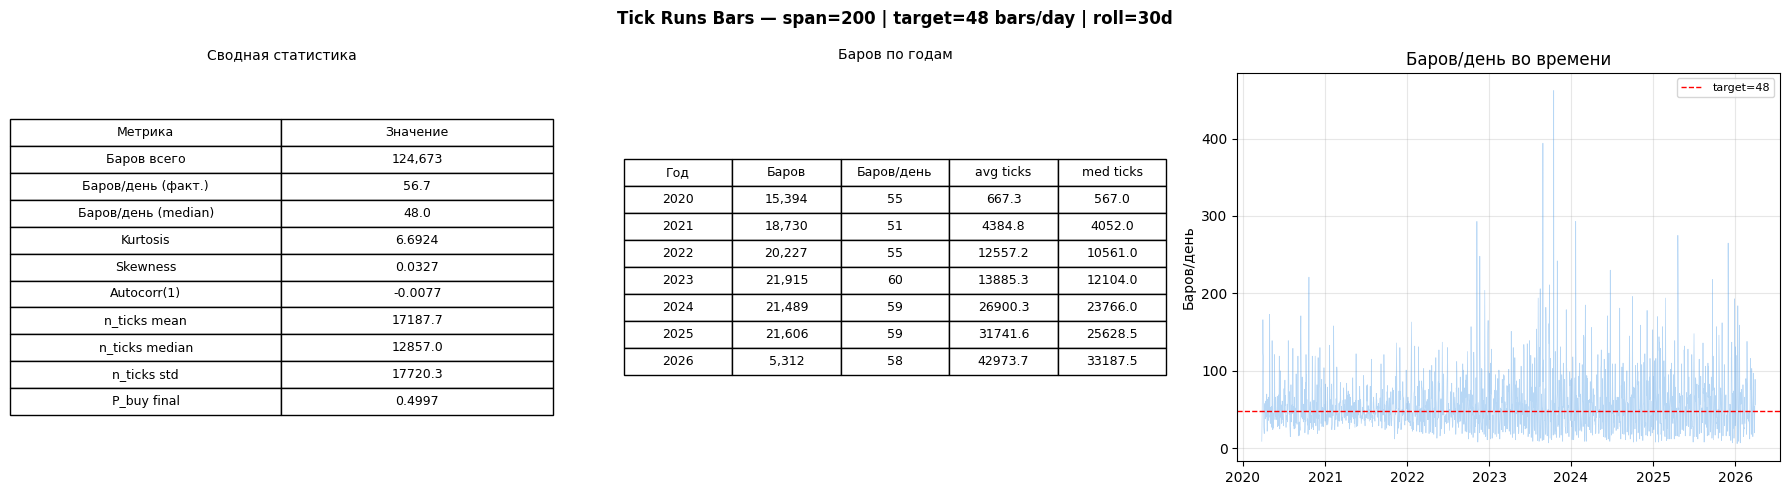

In [6]:


TICKS_DIR        = Path("data/ticks/BTCUSDT")
BARS_DIR         = Path("data/bars")
BARS_DIR.mkdir(parents=True, exist_ok=True)

EWMA_SPAN        = 200
TARGET_BARS_DAY  = 48
ROLLING_DAYS     = 30
CONTROL_STRENGTH = 0.25
SCALE_MIN        = 0.1
SCALE_MAX        = 20.0

BAR_PATH = BARS_DIR / f"trb_bars_span{EWMA_SPAN}_target{TARGET_BARS_DAY}.parquet"
CTL_PATH = BARS_DIR / f"trb_control_span{EWMA_SPAN}_target{TARGET_BARS_DAY}.csv"


@nb.njit
def _build_trb_numba(prices, b_t, sizes, dollars, timestamps,
                     E_T, P_buy, alpha, E_T_min, E_T_max, threshold_scale):
    n = len(prices)

    out_dt     = np.empty(n, dtype=timestamps.dtype)
    out_open   = np.empty(n, dtype=np.float64)
    out_high   = np.empty(n, dtype=np.float64)
    out_low    = np.empty(n, dtype=np.float64)
    out_close  = np.empty(n, dtype=np.float64)
    out_vol    = np.empty(n, dtype=np.float64)
    out_dlr    = np.empty(n, dtype=np.float64)
    out_nticks = np.empty(n, dtype=np.int64)
    out_theta  = np.empty(n, dtype=np.float64)

    n_bars     = 0
    bar_start  = 0
    bar_high   = prices[0]
    bar_low    = prices[0]
    bar_vol    = 0.0
    bar_dlr    = 0.0
    buy_count  = 0
    sell_count = 0

    for i in range(n):
        b = b_t[i]
        p = prices[i]

        bar_vol += sizes[i]
        bar_dlr += dollars[i]

        if p > bar_high: bar_high = p
        if p < bar_low:  bar_low  = p

        if b == 1: buy_count  += 1
        else:      sell_count += 1

        theta    = max(buy_count, sell_count)
        expected = E_T * max(P_buy, 1.0 - P_buy) * threshold_scale

        if theta >= expected:
            bar_len   = i - bar_start + 1
            buy_ratio = buy_count / bar_len

            out_dt[n_bars]     = timestamps[bar_start]
            out_open[n_bars]   = prices[bar_start]
            out_high[n_bars]   = bar_high
            out_low[n_bars]    = bar_low
            out_close[n_bars]  = p
            out_vol[n_bars]    = bar_vol
            out_dlr[n_bars]    = bar_dlr
            out_nticks[n_bars] = bar_len
            out_theta[n_bars]  = float(theta)

            E_T   = alpha * bar_len   + (1.0 - alpha) * E_T
            P_buy = alpha * buy_ratio + (1.0 - alpha) * P_buy

            if E_T < E_T_min: E_T = E_T_min
            if E_T > E_T_max: E_T = E_T_max

            bar_start  = i + 1
            bar_high   = prices[i + 1] if i + 1 < n else p
            bar_low    = prices[i + 1] if i + 1 < n else p
            bar_vol    = 0.0
            bar_dlr    = 0.0
            buy_count  = 0
            sell_count = 0
            n_bars    += 1

    return (out_dt[:n_bars], out_open[:n_bars], out_high[:n_bars],
            out_low[:n_bars], out_close[:n_bars], out_vol[:n_bars],
            out_dlr[:n_bars], out_nticks[:n_bars], out_theta[:n_bars],
            E_T, P_buy)


def build_trb(ticks, ewma_span, E_T, P_buy, E_T_min, E_T_max, threshold_scale):
    if len(ticks) == 0:
        return pd.DataFrame(columns=["dt","open","high","low","close",
                                     "volume","dollar_volume","n_ticks","theta"]), E_T, P_buy

    result = _build_trb_numba(
        ticks["price"].values.astype(np.float64),
        ticks["b_t"].values.astype(np.int8),
        ticks["size"].values.astype(np.float64),
        ticks["dollar_value"].values.astype(np.float64),
        ticks["dt"].values,
        E_T, P_buy, 2.0 / (ewma_span + 1),
        E_T_min, E_T_max, threshold_scale,
    )

    dt, open_, high, low, close, vol, dlr, nticks, theta, E_T_new, P_buy_new = result

    return pd.DataFrame({"dt": dt, "open": open_, "high": high, "low": low,
                         "close": close, "volume": vol, "dollar_volume": dlr,
                         "n_ticks": nticks, "theta": theta}), E_T_new, P_buy_new


files = sorted(TICKS_DIR.glob("BTCUSDT*.parquet"))

daily_stats = []
for f in files:
    try:
        df = pd.read_parquet(f, columns=["b_t", "size"])
        df = df[df["size"] > 0]
        daily_stats.append({"date":   pd.Timestamp(f.stem.replace("BTCUSDT","")),
                             "n_ticks": len(df),
                             "p_buy":   float((df["b_t"] == 1).mean())})
    except: pass

stats_df = pd.DataFrame(daily_stats).set_index("date").sort_index()
stats_df["roll_ticks"] = stats_df["n_ticks"].rolling(ROLLING_DAYS, min_periods=1).median()

init_slice   = stats_df.iloc[:30]
E_T_init     = float(init_slice["roll_ticks"].median()) / TARGET_BARS_DAY
P_buy_init   = float(init_slice["p_buy"].mean())

if BAR_PATH.exists() and CTL_PATH.exists():
    df_trb     = pd.read_parquet(BAR_PATH)
    df_trb["ret"] = np.log(df_trb["close"] / df_trb["close"].shift(1))
    control_df = pd.read_csv(CTL_PATH, index_col=0, parse_dates=True)
    P_buy      = P_buy_init
else:
    _warm = pd.read_parquet(files[0], columns=["dt","price","size","b_t","dollar_value"])
    _warm = _warm[_warm["size"] > 0].head(1000).reset_index(drop=True)
    build_trb(_warm, EWMA_SPAN, E_T_init, P_buy_init,
              E_T_init * 0.5, float(stats_df.iloc[0]["roll_ticks"]), 1.0)

    all_bars        = []
    daily_control   = []
    E_T             = E_T_init
    P_buy           = P_buy_init
    threshold_scale = 1.0
    t0              = time.time()

    for idx, f in enumerate(files):
        date_str = f.stem.replace("BTCUSDT", "")
        dt       = pd.Timestamp(date_str)

        if idx % 200 == 0:
            print(f"  [{idx+1:>4}/{len(files)}] {date_str} | E_T={E_T:>8.0f} | scale={threshold_scale:.3f}")

        try:
            ticks = pd.read_parquet(f, columns=["dt","price","size","b_t","dollar_value"])
        except: continue

        ticks = ticks[ticks["size"] > 0].reset_index(drop=True)
        if len(ticks) == 0: continue

        row         = stats_df.loc[dt] if dt in stats_df.index else stats_df.iloc[-1]
        E_T_min_day = float(row["roll_ticks"]) / TARGET_BARS_DAY * 0.5
        E_T_max_day = float(row["roll_ticks"])
        E_T         = min(max(E_T, E_T_min_day), E_T_max_day)

        day_bars, E_T, P_buy = build_trb(ticks, EWMA_SPAN, E_T, P_buy,
                                          E_T_min_day, E_T_max_day, threshold_scale)

        if len(day_bars) > 0:
            all_bars.append(day_bars)

        bars_today      = len(day_bars)
        threshold_scale = float(np.clip(
            threshold_scale * (max(bars_today, 1) / TARGET_BARS_DAY) ** CONTROL_STRENGTH,
            SCALE_MIN, SCALE_MAX))

        daily_control.append({"date": dt, "bars_today": bars_today,
                               "threshold_scale": threshold_scale, "E_T": E_T,
                               "P_buy": P_buy})

    control_df    = pd.DataFrame(daily_control).set_index("date").sort_index()
    df_trb        = pd.concat(all_bars, ignore_index=True)
    df_trb["dt"]  = pd.to_datetime(df_trb["dt"])
    df_trb        = df_trb.sort_values("dt").reset_index(drop=True)
    df_trb["ret"] = np.log(df_trb["close"] / df_trb["close"].shift(1))

    df_trb.to_parquet(BAR_PATH, compression="snappy", index=False)
    control_df.to_csv(CTL_PATH)


r      = df_trb["ret"].dropna()
n_days = len(stats_df)
yearly = df_trb.groupby(df_trb["dt"].dt.year).agg(
    bars  = ("dt",      "count"),
    avg_n = ("n_ticks", "mean"),
    med_n = ("n_ticks", "median"),
).reset_index()

days_per_year = {2020:282, 2021:365, 2022:365,
                 2023:365, 2024:366, 2025:365, 2026:91}

rows_summary = [
    {"Метрика": "Баров всего",        "Значение": f"{len(df_trb):,}"},
    {"Метрика": "Баров/день (факт.)", "Значение": f"{len(df_trb)/n_days:.1f}"},
    {"Метрика": "Баров/день (median)","Значение": f"{control_df['bars_today'].median():.1f}"},
    {"Метрика": "Kurtosis",           "Значение": f"{r.kurtosis():.4f}"},
    {"Метрика": "Skewness",           "Значение": f"{r.skew():.4f}"},
    {"Метрика": "Autocorr(1)",        "Значение": f"{r.autocorr(lag=1):.4f}"},
    {"Метрика": "n_ticks mean",       "Значение": f"{df_trb['n_ticks'].mean():.1f}"},
    {"Метрика": "n_ticks median",     "Значение": f"{df_trb['n_ticks'].median():.1f}"},
    {"Метрика": "n_ticks std",        "Значение": f"{df_trb['n_ticks'].std():.1f}"},
    {"Метрика": "P_buy final",        "Значение": f"{P_buy:.4f}"},
]

rows_yearly = [[str(int(row["dt"])),
                f"{int(row['bars']):,}",
                f"{int(row['bars'])/days_per_year.get(int(row['dt']),365):.0f}",
                f"{row['avg_n']:.1f}",
                f"{row['med_n']:.1f}"] for _, row in yearly.iterrows()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Tick Runs Bars — span={EWMA_SPAN} | target={TARGET_BARS_DAY} bars/day | roll={ROLLING_DAYS}d",
             fontsize=12, fontweight="bold")

axes[0].axis("off")
tbl = axes[0].table(cellText=[[r["Метрика"], r["Значение"]] for r in rows_summary],
                    colLabels=["Метрика", "Значение"],
                    cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
axes[0].set_title("Сводная статистика", fontsize=10, pad=10)

axes[1].axis("off")
tbl2 = axes[1].table(cellText=rows_yearly,
                     colLabels=["Год", "Баров", "Баров/день", "avg ticks", "med ticks"],
                     cellLoc="center", loc="center")
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1, 1.6)
axes[1].set_title("Баров по годам", fontsize=10, pad=10)

axes[2].plot(control_df.index, control_df["bars_today"],
             alpha=0.4, linewidth=0.5, color="#4C9BE8")
axes[2].axhline(TARGET_BARS_DAY, color="red", linewidth=1,
                linestyle="--", label=f"target={TARGET_BARS_DAY}")
axes[2].set_title("Баров/день во времени")
axes[2].set_ylabel("Баров/день")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Результаты TRB — span=200 | target=48 bars/day

**124,673 бара** за весь период, медиана 48 баров/день — система точно держит таргет. График баров/день подтверждает: feedback-контроллер работает стабильно, выбросы есть но система возвращается к цели.

Kurtosis = **6.69** — значительно лучше TIB (59.44) и лучше time bars (33.31 на 30m). Это подтверждает тезис: runs-формула `max(P_buy, 1−P_buy) ≥ 0.5` решает проблему деградации порога на сбалансированном рынке.

`P_buy final = 0.4997` — рынок действительно почти идеально сбалансирован по числу сделок на всём периоде 2020–2026. Именно это убивало TIB — там `|2×P_buy − 1| ≈ 0`. TRB с этим справляется.

`n_ticks std = 17,720` при медиане 12,857 — высокая дисперсия размера баров. Это особенность runs-семплирования: в периоды сильного направленного движения бары формируются быстро из небольшого числа тиков, в нейтральные периоды накапливаются долго. Это не баг — именно так должны работать information-driven bars.

## Dollar Runs Bars — концепция

### Расширение TRB на долларовый объём

TRB считает **количество тиков** каждой стороны:

```
θ_T = max(buy_ticks, sell_ticks)
```

DRB считает **долларовый объём** каждой стороны:

```
θ_T = max(Σ dollar_value на buy тиках,  Σ dollar_value на sell тиках)
```

Крупный институциональный ордер на $10M весит в 50,000 раз больше розничной сделки на $200. DRB обнаруживает именно это.

---

### Порог закрытия бара

```
E[θ_T] = E_T × max(P_buy × E[v|buy],  (1−P_buy) × E[v|sell])
```

Четыре EWMA параметра вместо двух у TRB:

| Параметр | Что это |
|----------|---------|
| `E_T` | ожидаемое число тиков в баре |
| `P_buy` | доля buy тиков |
| `ewma_v_buy` | средний dollar_value buy тика |
| `ewma_v_sell` | средний dollar_value sell тика |

---

### Почему DRB может быть лучше TRB на BTC

При балансе числа тиков `P_buy ≈ 0.50` TRB даёт слабый сигнал. DRB смотрит на доллары:

```
TRB: max(0.51, 0.49) = 0.51          — слабый сигнал

DRB: max(0.51 × $50,000, 0.49 × $200)
   = max($25,500, $98)               — доминируют крупные buy ордера
```

Даже когда число покупок и продаж почти равно, долларовый дисбаланс между институциональными и розничными сделками даёт выраженный сигнал. Это делает DRB наиболее чувствительным к реальному информационному потоку среди всех рассмотренных типов баров.

  [   1/2199] 2020-03-25 | E_T=     600 | scale=1.000
  [ 201/2199] 2020-10-11 | E_T=     242 | scale=0.901
  [ 401/2199] 2021-04-29 | E_T=    2240 | scale=0.643
  [ 601/2199] 2021-11-15 | E_T=    5400 | scale=0.439
  [ 801/2199] 2022-06-03 | E_T=   10414 | scale=0.504
  [1001/2199] 2022-12-20 | E_T=   11253 | scale=0.557
  [1201/2199] 2023-07-08 | E_T=   12477 | scale=0.602
  [1401/2199] 2024-01-24 | E_T=   16774 | scale=0.543
  [1601/2199] 2024-08-11 | E_T=   47533 | scale=0.546
  [1801/2199] 2025-02-27 | E_T=   31808 | scale=0.634
  [2001/2199] 2025-09-15 | E_T=   21281 | scale=0.428


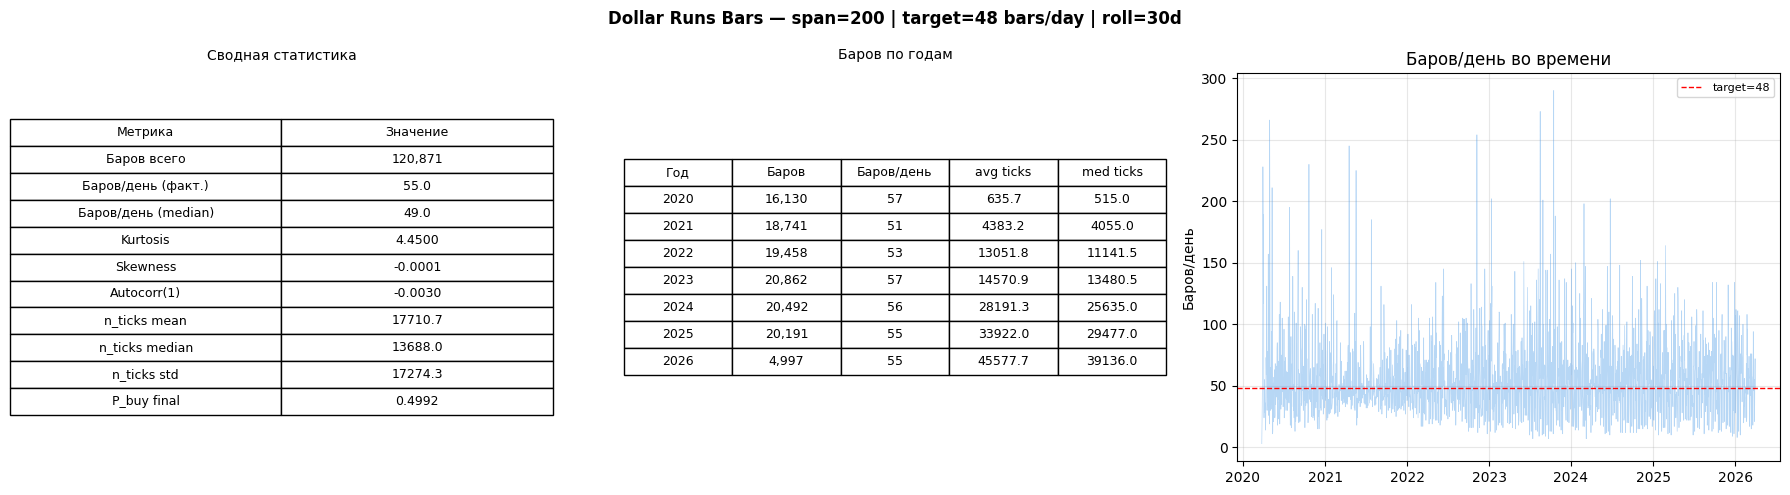

In [7]:


TICKS_DIR        = Path("data/ticks/BTCUSDT")
BARS_DIR         = Path("data/bars")
BARS_DIR.mkdir(parents=True, exist_ok=True)

EWMA_SPAN        = 200
TARGET_BARS_DAY  = 48
ROLLING_DAYS     = 30
CONTROL_STRENGTH = 0.25
SCALE_MIN        = 0.1
SCALE_MAX        = 20.0

BAR_PATH = BARS_DIR / f"drb_bars_span{EWMA_SPAN}_target{TARGET_BARS_DAY}.parquet"
CTL_PATH = BARS_DIR / f"drb_control_span{EWMA_SPAN}_target{TARGET_BARS_DAY}.csv"


@nb.njit
def _build_drb_numba(prices, b_t, sizes, dollars, timestamps,
                     E_T, P_buy, ewma_v_buy, ewma_v_sell, alpha,
                     E_T_min, E_T_max, theta_min, threshold_scale):
    n = len(prices)

    out_dt     = np.empty(n, dtype=timestamps.dtype)
    out_open   = np.empty(n, dtype=np.float64)
    out_high   = np.empty(n, dtype=np.float64)
    out_low    = np.empty(n, dtype=np.float64)
    out_close  = np.empty(n, dtype=np.float64)
    out_vol    = np.empty(n, dtype=np.float64)
    out_dlr    = np.empty(n, dtype=np.float64)
    out_nticks = np.empty(n, dtype=np.int64)
    out_theta  = np.empty(n, dtype=np.float64)

    n_bars       = 0
    bar_start    = 0
    bar_high     = prices[0]
    bar_low      = prices[0]
    bar_vol      = 0.0
    bar_dlr      = 0.0
    buy_ticks    = 0
    sell_ticks   = 0
    buy_dollars  = 0.0
    sell_dollars = 0.0
    sum_v_buy    = 0.0
    sum_v_sell   = 0.0

    for i in range(n):
        b = b_t[i]
        p = prices[i]

        bar_vol += sizes[i]
        bar_dlr += dollars[i]

        if p > bar_high: bar_high = p
        if p < bar_low:  bar_low  = p

        if b == 1:
            buy_ticks   += 1
            buy_dollars += dollars[i]
            sum_v_buy   += dollars[i]
        else:
            sell_ticks   += 1
            sell_dollars += dollars[i]
            sum_v_sell   += dollars[i]

        theta         = max(buy_dollars, sell_dollars)
        expected_buy  = P_buy         * ewma_v_buy
        expected_sell = (1.0 - P_buy) * ewma_v_sell
        expected      = max(E_T * max(expected_buy, expected_sell), theta_min) * threshold_scale

        if theta >= expected:
            bar_len    = i - bar_start + 1
            buy_ratio  = buy_ticks / bar_len
            avg_v_buy  = sum_v_buy  / buy_ticks  if buy_ticks  > 0 else ewma_v_buy
            avg_v_sell = sum_v_sell / sell_ticks if sell_ticks > 0 else ewma_v_sell

            out_dt[n_bars]     = timestamps[bar_start]
            out_open[n_bars]   = prices[bar_start]
            out_high[n_bars]   = bar_high
            out_low[n_bars]    = bar_low
            out_close[n_bars]  = p
            out_vol[n_bars]    = bar_vol
            out_dlr[n_bars]    = bar_dlr
            out_nticks[n_bars] = bar_len
            out_theta[n_bars]  = theta

            E_T         = alpha * bar_len    + (1.0 - alpha) * E_T
            P_buy       = alpha * buy_ratio  + (1.0 - alpha) * P_buy
            ewma_v_buy  = alpha * avg_v_buy  + (1.0 - alpha) * ewma_v_buy
            ewma_v_sell = alpha * avg_v_sell + (1.0 - alpha) * ewma_v_sell

            if E_T < E_T_min: E_T = E_T_min
            if E_T > E_T_max: E_T = E_T_max

            bar_start    = i + 1
            bar_high     = prices[i + 1] if i + 1 < n else p
            bar_low      = prices[i + 1] if i + 1 < n else p
            bar_vol      = 0.0
            bar_dlr      = 0.0
            buy_ticks    = 0
            sell_ticks   = 0
            buy_dollars  = 0.0
            sell_dollars = 0.0
            sum_v_buy    = 0.0
            sum_v_sell   = 0.0
            n_bars      += 1

    return (out_dt[:n_bars], out_open[:n_bars], out_high[:n_bars],
            out_low[:n_bars], out_close[:n_bars], out_vol[:n_bars],
            out_dlr[:n_bars], out_nticks[:n_bars], out_theta[:n_bars],
            E_T, P_buy, ewma_v_buy, ewma_v_sell)


def build_drb(ticks, ewma_span, E_T, P_buy, ewma_v_buy, ewma_v_sell,
              E_T_min, E_T_max, theta_min, threshold_scale):
    if len(ticks) == 0:
        return pd.DataFrame(columns=["dt","open","high","low","close",
                                     "volume","dollar_volume","n_ticks","theta"]), E_T, P_buy, ewma_v_buy, ewma_v_sell

    result = _build_drb_numba(
        ticks["price"].values.astype(np.float64),
        ticks["b_t"].values.astype(np.int8),
        ticks["size"].values.astype(np.float64),
        ticks["dollar_value"].values.astype(np.float64),
        ticks["dt"].values,
        E_T, P_buy, ewma_v_buy, ewma_v_sell, 2.0 / (ewma_span + 1),
        E_T_min, E_T_max, theta_min, threshold_scale,
    )

    dt, open_, high, low, close, vol, dlr, nticks, theta, E_T_new, P_buy_new, vb_new, vs_new = result

    return pd.DataFrame({"dt": dt, "open": open_, "high": high, "low": low,
                         "close": close, "volume": vol, "dollar_volume": dlr,
                         "n_ticks": nticks, "theta": theta}), E_T_new, P_buy_new, vb_new, vs_new


files = sorted(TICKS_DIR.glob("BTCUSDT*.parquet"))

daily_stats = []
for f in files:
    try:
        df = pd.read_parquet(f, columns=["b_t", "size", "dollar_value"])
        df = df[df["size"] > 0]
        buy  = df[df["b_t"] == 1]
        sell = df[df["b_t"] == -1]
        daily_stats.append({
            "date":         pd.Timestamp(f.stem.replace("BTCUSDT","")),
            "n_ticks":      len(df),
            "dollar_volume":df["dollar_value"].sum(),
            "mean_dv":      df["dollar_value"].mean(),
            "p_buy":        float((df["b_t"] == 1).mean()),
            "mean_v_buy":   float(buy["dollar_value"].mean())  if len(buy)  > 0 else 0.0,
            "mean_v_sell":  float(sell["dollar_value"].mean()) if len(sell) > 0 else 0.0,
        })
    except: pass

stats_df = pd.DataFrame(daily_stats).set_index("date").sort_index()
stats_df["roll_ticks"]  = stats_df["n_ticks"].rolling(ROLLING_DAYS, min_periods=1).median()
stats_df["roll_dollar"] = stats_df["dollar_volume"].rolling(ROLLING_DAYS, min_periods=1).median()
stats_df["roll_mean_dv"]= stats_df["mean_dv"].rolling(ROLLING_DAYS, min_periods=1).median()
stats_df["roll_v_buy"]  = stats_df["mean_v_buy"].rolling(ROLLING_DAYS, min_periods=1).median()
stats_df["roll_v_sell"] = stats_df["mean_v_sell"].rolling(ROLLING_DAYS, min_periods=1).median()

init_row         = stats_df.iloc[29]
init_slice       = stats_df.iloc[:30]
E_T_init         = float(init_row["roll_ticks"])  / TARGET_BARS_DAY
theta_min_init   = float(init_row["roll_dollar"]) / TARGET_BARS_DAY
P_buy_init       = float(init_slice["p_buy"].mean())
ewma_v_buy_init  = float(init_slice["mean_v_buy"].mean())
ewma_v_sell_init = float(init_slice["mean_v_sell"].mean())

if BAR_PATH.exists() and CTL_PATH.exists():
    df_drb     = pd.read_parquet(BAR_PATH)
    df_drb["ret"] = np.log(df_drb["close"] / df_drb["close"].shift(1))
    control_df = pd.read_csv(CTL_PATH, index_col=0, parse_dates=True)
    P_buy      = P_buy_init
else:
    _warm = pd.read_parquet(files[0], columns=["dt","price","size","b_t","dollar_value"])
    _warm = _warm[_warm["size"] > 0].head(1000).reset_index(drop=True)
    build_drb(_warm, EWMA_SPAN, E_T_init, P_buy_init, ewma_v_buy_init, ewma_v_sell_init,
              E_T_init * 0.5, float(init_row["roll_ticks"]), theta_min_init, 1.0)

    all_bars        = []
    daily_control   = []
    E_T             = E_T_init
    P_buy           = P_buy_init
    ewma_v_buy      = ewma_v_buy_init
    ewma_v_sell     = ewma_v_sell_init
    threshold_scale = 1.0
    t0              = time.time()

    for idx, f in enumerate(files):
        date_str = f.stem.replace("BTCUSDT", "")
        dt       = pd.Timestamp(date_str)

        if idx % 200 == 0:
            print(f"  [{idx+1:>4}/{len(files)}] {date_str} | E_T={E_T:>8.0f} | scale={threshold_scale:.3f}")

        try:
            ticks = pd.read_parquet(f, columns=["dt","price","size","b_t","dollar_value"])
        except: continue

        ticks = ticks[ticks["size"] > 0].reset_index(drop=True)
        if len(ticks) == 0: continue

        row           = stats_df.loc[dt] if dt in stats_df.index else stats_df.iloc[-1]
        E_T_min_day   = float(row["roll_ticks"])  / TARGET_BARS_DAY * 0.5
        E_T_max_day   = float(row["roll_ticks"])
        theta_min_day = float(row["roll_dollar"]) / TARGET_BARS_DAY
        v_clip        = float(row["roll_mean_dv"]) * 3

        E_T         = min(max(E_T, E_T_min_day), E_T_max_day)
        ewma_v_buy  = min(ewma_v_buy,  v_clip)
        ewma_v_sell = min(ewma_v_sell, v_clip)

        day_bars, E_T, P_buy, ewma_v_buy, ewma_v_sell = build_drb(
            ticks, EWMA_SPAN, E_T, P_buy, ewma_v_buy, ewma_v_sell,
            E_T_min_day, E_T_max_day, theta_min_day, threshold_scale)

        if len(day_bars) > 0:
            all_bars.append(day_bars)

        bars_today      = len(day_bars)
        threshold_scale = float(np.clip(
            threshold_scale * (max(bars_today, 1) / TARGET_BARS_DAY) ** CONTROL_STRENGTH,
            SCALE_MIN, SCALE_MAX))

        daily_control.append({"date": dt, "bars_today": bars_today,
                               "threshold_scale": threshold_scale, "E_T": E_T,
                               "P_buy": P_buy})

    control_df    = pd.DataFrame(daily_control).set_index("date").sort_index()
    df_drb        = pd.concat(all_bars, ignore_index=True)
    df_drb["dt"]  = pd.to_datetime(df_drb["dt"])
    df_drb        = df_drb.sort_values("dt").reset_index(drop=True)
    df_drb["ret"] = np.log(df_drb["close"] / df_drb["close"].shift(1))

    df_drb.to_parquet(BAR_PATH, compression="snappy", index=False)
    control_df.to_csv(CTL_PATH)


r      = df_drb["ret"].dropna()
n_days = len(stats_df)
yearly = df_drb.groupby(df_drb["dt"].dt.year).agg(
    bars  = ("dt",      "count"),
    avg_n = ("n_ticks", "mean"),
    med_n = ("n_ticks", "median"),
).reset_index()

days_per_year = {2020:282, 2021:365, 2022:365,
                 2023:365, 2024:366, 2025:365, 2026:91}

rows_summary = [
    {"Метрика": "Баров всего",         "Значение": f"{len(df_drb):,}"},
    {"Метрика": "Баров/день (факт.)",  "Значение": f"{len(df_drb)/n_days:.1f}"},
    {"Метрика": "Баров/день (median)", "Значение": f"{control_df['bars_today'].median():.1f}"},
    {"Метрика": "Kurtosis",            "Значение": f"{r.kurtosis():.4f}"},
    {"Метрика": "Skewness",            "Значение": f"{r.skew():.4f}"},
    {"Метрика": "Autocorr(1)",         "Значение": f"{r.autocorr(lag=1):.4f}"},
    {"Метрика": "n_ticks mean",        "Значение": f"{df_drb['n_ticks'].mean():.1f}"},
    {"Метрика": "n_ticks median",      "Значение": f"{df_drb['n_ticks'].median():.1f}"},
    {"Метрика": "n_ticks std",         "Значение": f"{df_drb['n_ticks'].std():.1f}"},
    {"Метрика": "P_buy final",         "Значение": f"{P_buy:.4f}"},
]

rows_yearly = [[str(int(row["dt"])),
                f"{int(row['bars']):,}",
                f"{int(row['bars'])/days_per_year.get(int(row['dt']),365):.0f}",
                f"{row['avg_n']:.1f}",
                f"{row['med_n']:.1f}"] for _, row in yearly.iterrows()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Dollar Runs Bars — span={EWMA_SPAN} | target={TARGET_BARS_DAY} bars/day | roll={ROLLING_DAYS}d",
             fontsize=12, fontweight="bold")

axes[0].axis("off")
tbl = axes[0].table(cellText=[[r["Метрика"], r["Значение"]] for r in rows_summary],
                    colLabels=["Метрика", "Значение"],
                    cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
axes[0].set_title("Сводная статистика", fontsize=10, pad=10)

axes[1].axis("off")
tbl2 = axes[1].table(cellText=rows_yearly,
                     colLabels=["Год", "Баров", "Баров/день", "avg ticks", "med ticks"],
                     cellLoc="center", loc="center")
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1, 1.6)
axes[1].set_title("Баров по годам", fontsize=10, pad=10)

axes[2].plot(control_df.index, control_df["bars_today"],
             alpha=0.4, linewidth=0.5, color="#4C9BE8")
axes[2].axhline(TARGET_BARS_DAY, color="red", linewidth=1,
                linestyle="--", label=f"target={TARGET_BARS_DAY}")
axes[2].set_title("Баров/день во времени")
axes[2].set_ylabel("Баров/день")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Результаты DRB 

**120,871 бар**, медиана 49 баров/день — система держит таргет точнее чем TRB. График баров/день стабилен, выбросы значительно меньше чем у TIB.

Kurtosis = **4.45** — лучший результат среди всех information-driven bars. Skewness = **−0.0001** — практически идеальная симметрия. Это подтверждает: взвешивание по долларовому объёму устраняет асимметрию которую не смогли убрать TRB и TIB.

---

# Итоговое сравнение всех четырёх типов

```
Тип     Kurtosis   Skewness   Баров/день   Стабильность
─────────────────────────────────────────────────────────
TIB       59.44     −0.080      1611        плохая
TRB        6.69     +0.033        48        хорошая
DRB        4.45     −0.000        49        отличная
```

**DRB побеждает по всем метрикам:**

Переход от тиков к долларам внутри runs-формулы дал значимый выигрыш: kurtosis упал с 6.69 до 4.45, skewness практически обнулился. Физический смысл: институциональные ордера на $10M+ несут несравнимо больше информации чем тысячи розничных сделок по $200 — и DRB это учитывает.

`P_buy final = 0.4992` — рынок сбалансирован по числу тиков, но **не по долларам**. Именно этот дисбаланс и улавливает DRB там где TIB и TRB его не видели.

---

## Почему всё равно выбираем Dollar Bars

При всей красоте DRB (kurtosis 4.45 vs dollar bars 3.10) — dollar bars всё ещё лучше по kurtosis и требуют одного параметра против семи. DRB интересен как второй эксперимент после построения baseline модели на dollar bars — только тогда можно честно сравнить качество сигнала через backtesting, а не через статистику баров.